In [1]:
import phoebe
import lightkurve as lk

import sys
sys.path.insert(1, '../scripts')
import phoebe_to_eBEER

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from astropy import units as u

from scipy.linalg import lstsq
from scipy.optimize import curve_fit


PHOEBE: passband "Bolometric:900-40000" has a newer version available.  Run phoebe.list_passband_online_history("Bolometric:900-40000") to get a list of available changes and phoebe.update_passband("Bolometric:900-40000") or phoebe.update_all_passbands() to update.
PHOEBE: passband "Johnson:V" has a newer version available.  Run phoebe.list_passband_online_history("Johnson:V") to get a list of available changes and phoebe.update_passband("Johnson:V") or phoebe.update_all_passbands() to update.


# Testing Utils

In [2]:
def get_phoebe_binary(Porb= 1, t0= -0.25, M1= 0.9988131358058301, 
                      M2= 0.9988131358058301, R1= 1, R2= 1, T1= 6000, T2= 6000,
                      incl= 90, per0= 0, ecc= 0, u1= 0.5, u2= 0.5, tau1= 0.32,
                      tau2= 0.32, metallicity= None):
    """Configure a PHOEBE binary with input parameters"""
    # ??? Assumes Prot of stars = Porb of system (default PHOEBE behavior)
    # Init with PHOEBE system defaults

    binary = phoebe.default_binary()

    binary['primary']['teff'].set_value(T1 * u.K)
    binary['secondary']['teff'].set_value(T2 * u.K)

    orbit = binary['orbit']
    orbit['period'].set_value(Porb * u.day)

    orbit['incl'].set_value(incl * u.deg)

    orbit['ecc'].set_value(ecc)
    orbit['per0'].set_value(per0 * u.deg)

    binary.flip_constraint('mass@primary', solve_for='sma')
    binary.flip_constraint('mass@secondary', solve_for='q')
    binary['primary']['mass'].set_value(M1 * u.M_sun)
    binary['secondary']['mass'].set_value(M2 * u.M_sun)

    binary['primary']['requiv'].set_value(R1 * u.R_sun)
    binary['secondary']['requiv'].set_value(R2 * u.R_sun)

    binary.flip_constraint('t0_perpass', solve_for= 't0_supconj')
    orbit['t0_perpass'].set_value(t0 * u.day)
    
    for component in ['primary', 'secondary']:
        binary[component]['ld_mode_bol'].set_value('manual')
        binary[component]['ld_func_bol'].set_value('linear')
    
    binary['primary']['ld_coeffs_bol'].set_value(u1)
    binary['secondary']['ld_coeffs_bol'].set_value(u2)
    binary['primary']['gravb_bol'].set_value(tau1)
    binary['secondary']['gravb_bol'].set_value(tau2)

    if (metallicity is not None):
        binary['primary@abun'] = metallicity
        binary['secondary@abun'] = metallicity

    return binary

In [3]:
def prefit_eval(binary, times, flux_to_fit):
    Porb = binary['orbit@period'].get_value(u.day)
    t0_perpass = binary['orbit@t0_perpass'].get_value(u.day)
    flux = phoebe_to_eBEER.get_eBEER_lc(binary, times, 0,0,0,0)
    phase = (times) % Porb

    plt.figure(figsize=(16,5), label= 'Gauge initial guess for time shift')
    plt.subplot(121)
    plt.plot(times, flux_to_fit, 'b.', markersize= 1, label= 'Flux to fit')
    plt.plot(times, flux, 'r', label= 'eBEER w/o beaming or reflection')
    plt.legend()

    plt.subplot(122)
    plt.plot(phase, flux_to_fit, 'b.', markersize= 1, label= 'Flux to fit')
    plt.plot(phase, flux, 'r', label= 'eBEER w/o beaming or reflection')
    plt.legend()

# Engel et al. 2020 System Params

In [4]:
systems = ('KIC6292925', 'KIC5200778', 'KIC4931390')

KIC6292925 = {
    "Fitted Model": ['eBEER', 'PHOEBE'],
    "Porb": [13.6126, 13.6122],
    "t0_perpass": [874.04, 875.977],
    "M1": [1.9, 1.89],
    "M2": [0.50, 0.50],
    "R1": [1.8, 1.80],
    "R2": [1.3, 1.10],
    "T1": [8300, 8400],
    "T2": [6000, 7000],
    "incl": [71, 72],
    "per0": [157, 153],
    "ecc": [0.232, 0.2491],
    # Following found in MAST data and through ExoCTK calculations
    "metallicity": [0.087, 0.087],
    "u1": [0.622, 0.606], # ??? Had to use Kurucz ATLAS9 Model as the Phoenix ACES model (better for Kepler Bandpass) doesnt cover Teff range
    "u2": [0.741, 0.616],
}

KIC5200778 = {
    "Fitted Model": ['eBEER', 'PHOEBE'],
    "Porb": [16.357, 16.3536],
    "t0_perpass": [806.6, 804.2],
    "M1": [1.2, 1.20],
    "M2": [0.40, 0.37],
    "R1": [2.4, 2.30],
    "R2": [0.14, 0.47],
    "T1": [6000, 6500],
    "T2": [4000, 3500],
    "incl": [23, 24],
    "per0": [-1, 2],
    "ecc": [0.35, 0.26],
    # Following found in MAST data and through ExoCTK calculations
    "metallicity": [None,None], # ??? Not available in MAST table so defaulting to 0
    "u1": [0.741, 0.687],
    "u2": [0.577, 0.774],
}

KIC4931390 = {
    "Fitted Model": ['eBEER', 'PHOEBE'],
    "Porb": [7.6064, 7.6080],
    "t0_perpass": [798.44, 794.78],
    "M1": [1.20, 1.10],
    "M2": [0.10, 0.13],
    "R1": [1.48, 1.42],
    "R2": [0.7, 0.66],
    "T1": [6500, 6620],
    "T2": [5500, 6500],
    "incl": [50, 35],
    "per0": [158, 160],
    "ecc": [0.08, 0.040],
    # Following found in MAST data and through ExoCTK calculations
    "metallicity": [-0.313, -0.313],
    "u1": [0.695, 0.693],
    "u2": [0.736, 0.695],
}

dfs = (KIC6292925, KIC5200778, KIC4931390)

def grab_fit_params(df, idx):
    cur_fit_params = df.loc[idx]
    fit_type = cur_fit_params['Fitted Model']
    Porb = cur_fit_params['Porb']
    t0_perpass = cur_fit_params['t0_perpass']
    M1 = cur_fit_params['M1']
    M2 = cur_fit_params['M2']
    R1 = cur_fit_params['R1']
    R2 = cur_fit_params['R2']
    T1 = cur_fit_params['T1']
    T2 = cur_fit_params['T2']
    incl = cur_fit_params['incl']
    per0 = cur_fit_params['per0']
    ecc = cur_fit_params['ecc']
    u1 = cur_fit_params['u1']
    u2 = cur_fit_params['u2']
    abun = cur_fit_params['metallicity']
    pb = get_phoebe_binary(Porb, t0_perpass, M1, M2, R1, R2, T1, T2, incl, per0, ecc, u1, u2, metallicity= abun)
    return fit_type, pb

# Select System

In [17]:
i = 1
target_name = systems[i]
df = pd.DataFrame(dfs[i])
fit_type_, phoebe_binary_ = grab_fit_params(df, 0)
kp = phoebe_to_eBEER.eBEERParams(phoebe_binary_, times= 0) # Kepler Fit Params Wrapper
print(target_name, fit_type_)

KIC5200778 eBEER


# Detrending

In [18]:
def four_sigma_clip(time, flux, sigma=4):
    """Perform 4-sigma clipping with running median and rms to remove outliers """
    medians = np.zeros(len(flux))
    rmss = np.zeros(len(flux))
    for i in range(len(flux)):
        window = flux[max(0, i - 15) : min(len(flux), i + 15 + 1)]
        window = np.asarray(window)
        median = np.median(window)
        rms = np.sqrt(np.mean((window - median)**2))
        medians[i] = median
        rmss[i] = rms
    
    mask = np.abs(flux - medians) <= sigma * rmss
    return time[mask], flux[mask]
    

def cosine_transform_detrending(time, flux, Porb):
    T = time[-1] - time[0]
    max_freq = 0.1  # d^-1
    cust_factor = 1
    # N = int(np.floor(max_freq * 2 * T)) * cust_factor
    N = round((2 * T) / (Porb))
    print(N)

    def cosine_basis(t, i):
        return np.cos((2 * np.pi / (2 * T)) * i * t)
    # Create the design matrix using the cosine basis functions
    A = np.array([cosine_basis(time, i) for i in range(0, N+1)]).T
    # Solve for the linear coefficients using least squares
    coeffs, _, _, _ = lstsq(A, flux)
    # Calculate the model flux
    model_flux = np.dot(A, coeffs)
    # Subtract the model from the original flux to get the detrended flux
    detrended_flux_lalg = flux - model_flux
    
    return detrended_flux_lalg, model_flux

8


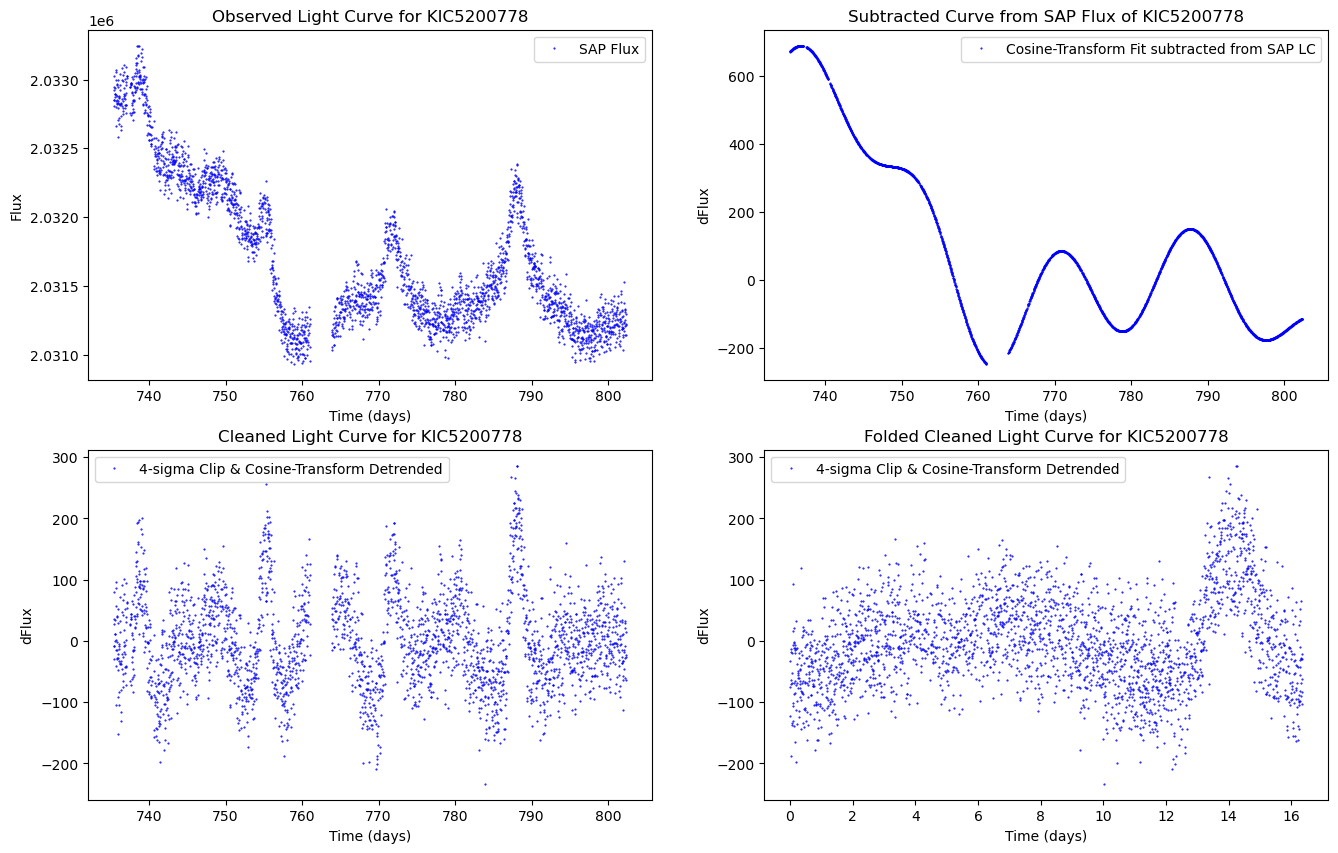

In [19]:
# Search and download light curve files
quarter = 8
search_result = lk.search_lightcurve(target_name, mission='Kepler', quarter= quarter, cadence='long')
lightcurves = search_result.download_all()

lc_df = lightcurves[0]
qual = lc_df.quality.value
time = np.array(lc_df.time.value)
time = time[qual ==0]
sap_flux = np.array(lc_df.sap_flux.value)
sap_flux = sap_flux[qual ==0]

# print(np.max(np.where(time[time<355])))

plt.figure(figsize=(16, 10))
plt.subplot(221)
plt.plot(time, sap_flux, 'b.', markersize=1, label='SAP Flux')
plt.title(f'Observed Light Curve for {target_name}')
plt.xlabel('Time (days)')
plt.ylabel('Flux')
plt.legend()

flux_med = np.median(sap_flux)
sap_flux = (sap_flux - flux_med) / flux_med * 1e6

time, clipped_flux = four_sigma_clip(time, sap_flux)
# print(len(time), len(clipped_flux))
detrended_flux, detrend_model_flux = cosine_transform_detrending(time, clipped_flux, kp.Porb)
phase = (time - kp.t0) % kp.Porb

plt.subplot(222)
plt.plot(time, detrend_model_flux, 'b.', markersize=1, label='Cosine-Transform Fit subtracted from SAP LC')
plt.title(f'Subtracted Curve from SAP Flux of {target_name}')
plt.xlabel('Time (days)')
plt.ylabel('dFlux')
plt.legend()

# time = time[125:]
# phase = phase[125:]
# detrended_flux = detrended_flux[125:]

plt.subplot(223)
plt.plot(time, detrended_flux, 'b.', markersize=1, label='4-sigma Clip & Cosine-Transform Detrended')
plt.title(f'Cleaned Light Curve for {target_name}')
plt.xlabel('Time (days)')
plt.ylabel('dFlux')
plt.legend()

plt.subplot(224)
plt.plot(phase, detrended_flux, 'b.', markersize=1, label='4-sigma Clip & Cosine-Transform Detrended')
plt.title(f'Folded Cleaned Light Curve for {target_name}')
plt.xlabel('Time (days)')
plt.ylabel('dFlux')
plt.legend()

## Run Fit

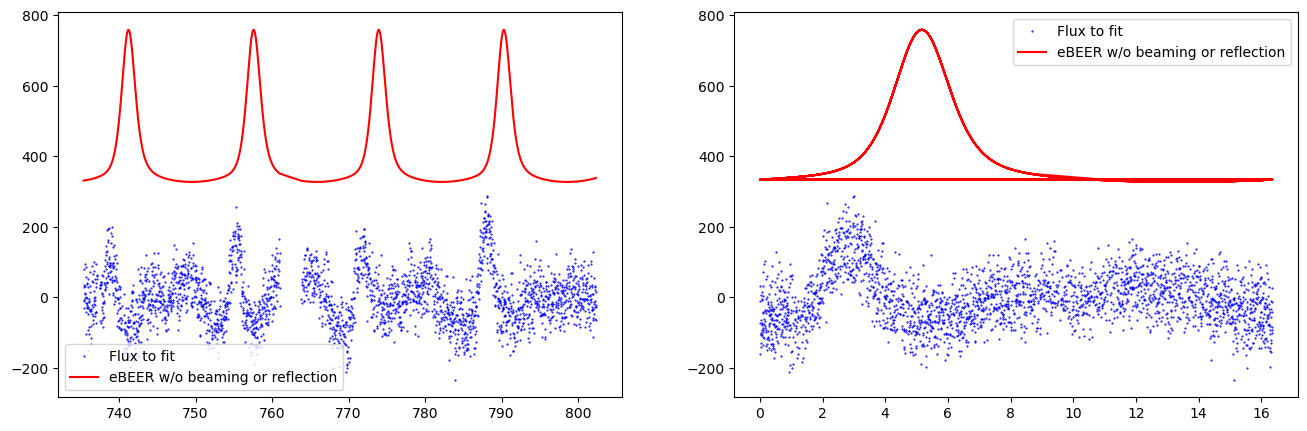

In [20]:
prefit_eval(phoebe_binary_, time, detrended_flux)

In [21]:
def fit_scaling_Kepler(time_shift, abeam1, abeam2, arefl1, arefl2):
    scaled = np.zeros(6)
    scaled[0] = time_shift * kp.Porb
    scaled[1] = abeam1 * 3
    scaled[2] = abeam2 * 3
    scaled[3] = arefl1 * 7
    scaled[4] = arefl2 * 7
    return scaled

def fit_eBEER_Kepler(t, time_shift, abeam1, abeam2, arefl1, arefl2):
   
  scaled = fit_scaling_Kepler(time_shift, abeam1, abeam2, arefl1, arefl2)

  flux = (phoebe_to_eBEER.get_eBEER_lc(phoebe_binary_, (t + scaled[0]) % kp.Porb, scaled[1], scaled[2], scaled[3], scaled[4])) / 1e6

  detrended_eBEER = (flux - np.median(flux)) / (1 + np.median(flux)) * 1e6

  # detrended_eBEER, _ = cosine_transform_detrending(t, flux, kp.Porb)
  
  return detrended_eBEER

In [22]:
popt_, pcov_ = curve_fit(fit_eBEER_Kepler, time, detrended_flux, p0= ((2)/kp.Porb, 0.5, 0.5, 0.5, 0.5), bounds= ([0, 0, 0, 0, 0], [1, 1, 1, 1, 1]))
print(popt_)
print(np.sqrt(np.diag(pcov_))*np.array((kp.Porb, 3, 3, 7, 7)))

[0.14057659 0.4106815  0.59044232 0.17629758 0.602902  ]
[1.70408465e-02 1.34060810e+03 6.64792229e+05 1.83678423e+00
 9.70926440e+00]


In [23]:
fit_params_ = ('Time Shift', 'Alpha Beaming 1', 'Alpha Beaming 2', 'Alpha Reflective 1', 'Alpha Reflective 2')
rescaled_ = fit_scaling_Kepler(popt_[0], popt_[1], popt_[2], popt_[3], popt_[4])
for name,value in zip(fit_params_, rescaled_):
    print(name+':', value)

Time Shift: 2.2994113487550396
Alpha Beaming 1: 1.2320444990488397
Alpha Beaming 2: 1.771326951901699
Alpha Reflective 1: 1.2340830367390352
Alpha Reflective 2: 4.220313997850389


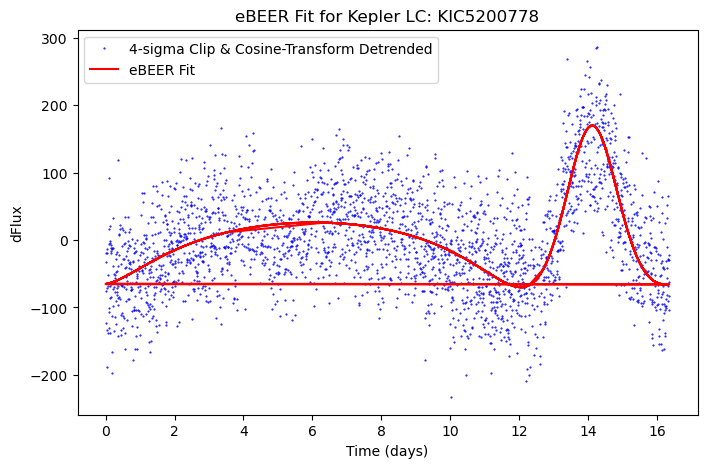

In [24]:
fit_flux_ = fit_eBEER_Kepler(time, popt_[0], popt_[1], popt_[2], popt_[3], popt_[4])

plt.figure(figsize=(8, 5))
plt.plot(phase, detrended_flux, 'b.', markersize=1, label='4-sigma Clip & Cosine-Transform Detrended')
plt.plot(phase, fit_flux_, 'r',  label='eBEER Fit')
plt.title(f'eBEER Fit for Kepler LC: {target_name}')
plt.xlabel('Time (days)')
plt.ylabel('dFlux')
plt.legend()

In [30]:
dif = np.abs(fit_flux_ - detrended_flux)
MSD = np.sqrt(np.mean(dif**2))

print(f'Mean Diff: {np.mean(dif)} ppm   STD: {np.std(dif)} ppm')
print(f'MSD: {MSD} ppm')

Mean Diff: 46.4573126489437 ppm   STD: 34.365556434790946 ppm
MSD: 57.78644622776612 ppm


# Additional Fit Validation


In [ ]:
eBp = phoebe_to_eBEER.eBEERParams(phoebe_binary_, time)
beaming_mod1 = phoebe_to_eBEER.Mbeam(eBp, rescaled_[1])
beaming_mod2 = phoebe_to_eBEER.Mbeam(eBp, rescaled_[2], False)
secondary_flux_fraction = (
        phoebe_binary_['secondary@teff'].get_value('K')
        /
        phoebe_binary_['primary@teff'].get_value('K')
    )**4 * (eBp.R2 / eBp.R1)**2
beaming_tot = (beaming_mod1 + secondary_flux_fraction * beaming_mod2) / (1 + secondary_flux_fraction)

ellip_mod1 = phoebe_to_eBEER.Mellip(eBp)
ellip_mod2 = phoebe_to_eBEER.Mellip(eBp, False)
secondary_flux_fraction = (
        phoebe_binary_['secondary@teff'].get_value('K')
        /
        phoebe_binary_['primary@teff'].get_value('K')
    )**4 * (eBp.R2 / eBp.R1)**2
ellip_tot = (ellip_mod1 + secondary_flux_fraction * ellip_mod2) / (1 + secondary_flux_fraction)

refl_mod1 = phoebe_to_eBEER.Mrefl(eBp, rescaled_[3])
refl_mod2 = phoebe_to_eBEER.Mrefl(eBp, rescaled_[4], False)
secondary_flux_fraction = (
        phoebe_binary_['secondary@teff'].get_value('K')
        /
        phoebe_binary_['primary@teff'].get_value('K')
    )**4 * (eBp.R2 / eBp.R1)**2
refl_tot = (refl_mod1 + secondary_flux_fraction * refl_mod2) / (1 + secondary_flux_fraction)
sum = beaming_tot + ellip_tot + refl_tot

plot_beaming = (beaming_tot/1e6 - np.median(beaming_tot/1e6)) / (1 + np.median(beaming_tot/1e6)) * 1e6
plot_ellip = (ellip_tot/1e6 - np.median(ellip_tot/1e6)) / (1 + np.median(ellip_tot/1e6)) * 1e6
plot_refl = (refl_tot/1e6 - np.median(refl_tot/1e6)) / (1 + np.median(refl_tot/1e6)) * 1e6
plot_sum = (sum/1e6 - np.median(sum/1e6)) / (1 + np.median(sum/1e6)) * 1e6

# plot_beaming, _ = cosine_transform_detrending(time, beaming_tot, kp.Porb)
# plot_ellip, _ = cosine_transform_detrending(time, ellip_tot, kp.Porb)
# plot_refl, _ = cosine_transform_detrending(time, refl_tot, kp.Porb)
# plot_sum, _ = cosine_transform_detrending(time, sum, kp.Porb)


Abeam = (np.max(plot_beaming) - np.min(plot_beaming))/2
Aellip = (np.max(plot_ellip) - np.min(plot_ellip))/2
Arefl = (np.max(plot_refl) - np.min(plot_refl))/2
print(f'Abeam: {Abeam}, Aellip: {Aellip}, Arefl:{Arefl}')

plt.plot(phase, plot_beaming, label= 'beam')
plt.plot(phase, plot_ellip, label= 'ellip')
plt.plot(phase, plot_refl, label= 'refl')
plt.plot(phase, plot_sum, label= 'sum')
plt.legend()
